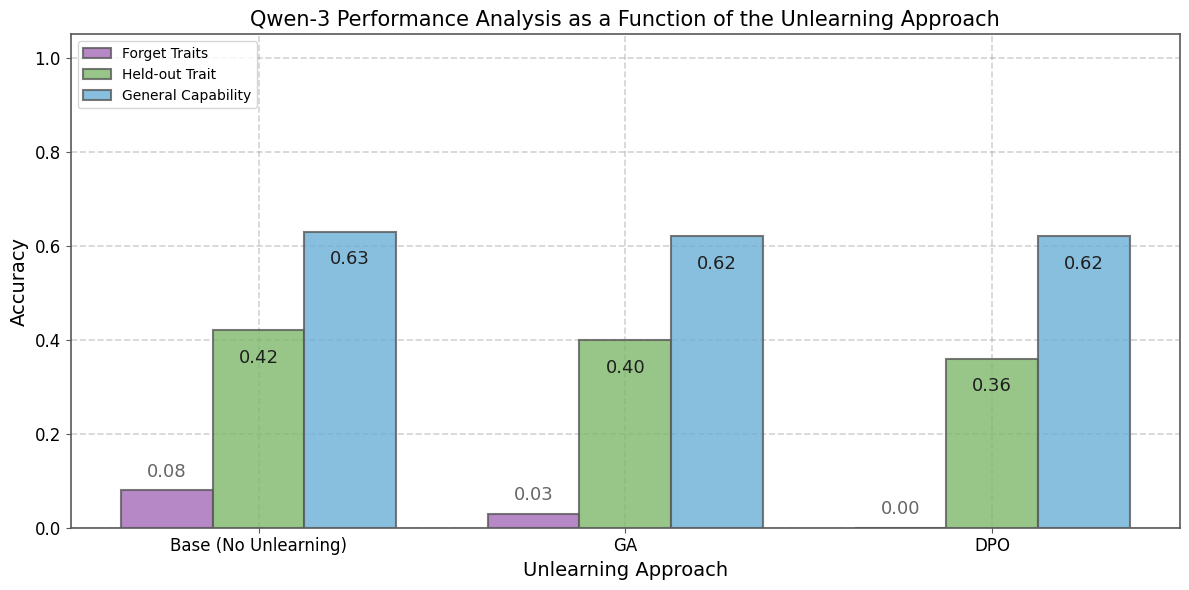

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# ---------- Base settings ----------
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial', 'Liberation Sans', 'sans-serif'],
    'axes.titlesize': 15,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
})

_success_color = '#7EB86A'  # Held-out (green)
_fail_color    = '#A56AB8'  # Forget (purple)
_general_color = '#6BAED6'  # General capability (blue-ish)
_edge_color    = '#595959'


def _style_axes(ax):
    ax.grid(True, linestyle='--', color='gray', alpha=0.35, linewidth=1.2, zorder=0)
    for side in ['left', 'bottom', 'top', 'right']:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_color(_edge_color)
        ax.spines[side].set_linewidth(1.2)
    ax.tick_params(axis='both', labelsize=12, color=_edge_color)


def _add_value_labels(ax, rects, fmt='{:.2f}', min_inside=0.12, fontsize=13):
    """Add centered labels; if bar is short, put label just above the bar."""
    for r in rects:
        height = r.get_height()
        x = r.get_x() + r.get_width() / 2.0
        if height >= min_inside:
            ax.text(x, height - (0.04 if height >= 0.2 else 0.02),
                    fmt.format(height), ha='center', va='top',
                    fontsize=fontsize, color='#1f1f1f', zorder=4)
        else:
            ax.text(x, height + 0.02, fmt.format(height),
                    ha='center', va='bottom', fontsize=fontsize, zorder=4, color='#666666')


# ---------- Data ----------
labels = ['Base (No Unlearning)', 'GA', 'DPO']

forget_vals = [0.08, 0.03, 0.00]
held_vals   = [0.42, 0.40, 0.36]
general_vals = [0.63, 0.62, 0.62]

# ---------- Plot ----------
fig, ax = plt.subplots(figsize=(12, 6))
_style_axes(ax)

x = np.arange(len(labels))
width = 0.25  # narrower bars since we now have 3 per group

bars_forget = ax.bar(
    x - width, forget_vals, width,
    label='Forget Traits', color=_fail_color, alpha=0.8,
    edgecolor=_edge_color, linewidth=1.5, zorder=3
)
bars_held = ax.bar(
    x, held_vals, width,
    label='Held-out Trait', color=_success_color, alpha=0.8,
    edgecolor=_edge_color, linewidth=1.5, zorder=3
)
bars_general = ax.bar(
    x + width, general_vals, width,
    label='General Capability', color=_general_color, alpha=0.8,
    edgecolor=_edge_color, linewidth=1.5, zorder=3
)

# Labels & ticks
ax.set_xticks(x)
ax.set_xticklabels([lbl for lbl in labels], rotation=0)
ax.set_ylabel("Accuracy")
ax.set_xlabel("Unlearning Approach")
ax.set_title("Qwen-3 Performance Analysis as a Function of the Unlearning Approach")
ax.set_ylim(0, 1.05)

# Value labels
_add_value_labels(ax, bars_forget, fmt='{:.2f}')
_add_value_labels(ax, bars_held, fmt='{:.2f}')
_add_value_labels(ax, bars_general, fmt='{:.2f}')

# Legend
ax.legend(loc='upper left', frameon=True)

plt.tight_layout()
plt.savefig("part2_grouped_bar_freeform_with_general.pdf", dpi=300, bbox_inches='tight')
plt.show()
